In [1]:
# Instalar dependencias
%pip install -r ./requirements.txt


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import seaborn as sns

I0000 00:00:1779024351.503983  192838 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779024351.504812  192838 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779024351.600579  192838 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779024354.305500  192838 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## Fuentes
- https://www.geeksforgeeks.org/deep-learning/multi-layer-perceptron-learning-in-tensorflow/
- https://www.geeksforgeeks.org/machine-learning/activation-functions-neural-networks/
- https://medium.com/@artjovianprojects/deep-learning-project-multilayer-perceptron-e34017941918

## Carga de datos
Los datos fueron preprocesados en Ciencia de Datos: se eliminaron valores atípicos, se seleccionaron variables relevantes y se aplicó estandarización (Z-score).

Se cargan los conjuntos de entrenamiento y test ya preparados.

In [3]:
train = pd.read_csv("./data/train.csv")
test = pd.read_csv("./data/test.csv")

In [4]:
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nDistribución del target en train:\n{train['target'].value_counts()}")
print(f"\nDistribución del target en test:\n{test['target'].value_counts()}")
train.describe()

Train shape: (11616, 9)
Test shape: (2905, 9)

Distribución del target en train:
target
1    5985
0    5631
Name: count, dtype: int64

Distribución del target en test:
target
1    1497
0    1408
Name: count, dtype: int64


,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],product_type_H,product_type_L,product_type_M,target
count,11616.000000,1.161600e+04,1.161600e+04,1.161600e+04,1.161600e+04,11616.000000,11616.000000,11616.000000,11616.000000
mean,0.000893,-9.517333e-15,-1.492531e-16,-1.761676e-16,-1.896249e-17,0.101756,0.714618,0.183626,0.515238
std,0.999587,1.000043e+00,1.000043e+00,1.000043e+00,1.000043e+00,0.302340,0.451616,0.387196,0.499789
min,-2.668586,-3.376150e+00,-1.163861e+00,-2.896833e+00,-1.789705e+00,0.000000,0.000000,0.000000,0.000000
25%,-0.814256,-7.301602e-01,-5.412473e-01,-6.318700e-01,-8.622280e-01,0.000000,0.000000,0.000000,0.000000
50%,0.061400,1.392366e-01,-3.115130e-01,1.264018e-01,5.098029e-02,0.000000,1.000000,0.000000,1.000000
75%,0.885547,6.911146e-01,1.412966e-01,7.041662e-01,9.641886e-01,0.000000,1.000000,0.000000,1.000000
max,2.070259,2.747427e+00,4.556190e+00,2.218599e+00,1.820321e+00,1.000000,1.000000,1.000000,1.000000


In [5]:
train

,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],product_type_H,product_type_L,product_type_M,target
0,-1.586893,-1.334958,-0.587860,0.509232,-1.090530,0.0,1.0,0.0,0
1,-1.483875,-1.108159,-0.364785,0.692203,0.307820,0.0,0.0,1.0,0
2,-1.205725,-1.478597,-0.321501,1.317821,-1.518596,0.0,1.0,0.0,1
3,0.452870,0.675995,-0.221617,0.240406,1.221028,0.0,1.0,0.0,1
4,-1.071801,-0.654560,-0.361455,-0.131164,0.578929,0.0,1.0,0.0,0
...,...,...,...,...,...,...,...,...,...
11611,0.864944,0.751594,-0.368114,0.849135,1.178222,0.0,1.0,0.0,1
11612,0.473474,0.328236,-0.241594,-0.074866,1.206760,0.0,1.0,0.0,0
11613,0.164419,1.386632,-0.135050,-0.539329,0.550391,0.0,1.0,0.0,0
11614,0.731020,0.456755,-0.731028,1.384676,-1.033455,0.0,1.0,0.0,1


In [6]:
test

,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],product_type_H,product_type_L,product_type_M,target
0,-0.968783,-0.276562,-0.041825,0.051806,0.265013,0.0,1.0,0.0,0
1,-0.597917,-0.669680,-0.218287,-0.219835,1.178222,0.0,1.0,0.0,1
2,1.658185,2.067030,-0.191652,0.340336,-1.761167,1.0,0.0,0.0,0
3,0.937057,-0.049763,0.151285,-0.504143,-1.347370,0.0,0.0,1.0,0
4,1.658185,1.613431,-0.474658,0.086993,-0.391355,0.0,1.0,0.0,0
...,...,...,...,...,...,...,...,...,...
2900,-0.324918,0.063637,-0.477987,1.305858,-0.519775,0.0,1.0,0.0,1
2901,-0.608219,-1.032559,-0.401409,0.030694,0.935651,1.0,0.0,0.0,0
2902,-0.834859,-0.397521,0.604095,-1.215616,0.479047,0.0,1.0,0.0,1
2903,-0.036467,0.184596,3.946895,-2.435185,0.093787,0.0,1.0,0.0,1


## Actividades

Separación de features (X) y target (y) para ambos conjuntos

In [7]:
X_train = train.drop(columns=['target'])
y_train = train['target']
X_test = test.drop(columns=['target'])
y_test = test['target']

print(f"Features de entrada: {X_train.shape[1]} ({list(X_train.columns)})")

Features de entrada: 8 (['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]', 'product_type_H', 'product_type_L', 'product_type_M'])


### Actividad 1

#### Decisiones de diseño

Input(8) → Dense(32, relu) → Dropout → Dense(32, relu) → Dropout → Dense(1, sigmoid).

**Arquitectura MLP (capas ocultas → 1 neurona de salida):**
- Se utiliza un patrón "embudo" (neuronas decrecientes) que fuerza a la
  red a comprimir progresivamente la representación de los datos.
- Con solo 5 features de entrada, una red de 2 capas ocultas es suficiente
  para capturar relaciones no lineales sin sobreajustar.

**Funciones de activación:**
- **ReLU** en capas ocultas: es el estándar porque evita el problema
  de "vanishing gradient" y es computacionalmente eficiente.
- **Sigmoid** en la capa de salida: mapea la salida al rango [0, 1],
  interpretable como la probabilidad de falla (clase positiva).
  Se usa sigmoid (y no softmax) porque tenemos 1 sola neurona de salida
  para clasificación binaria. Softmax se emplea cuando hay 2+ neuronas de
  salida (clasificación multiclase), ya que normaliza un vector para que
  las probabilidades sumen 1.

**Regularización (Dropout):**
- Durante el entrenamiento, se "apagan" aleatoriamente un porcentaje de las
  neuronas en cada paso. Esto evita co-adaptación y reduce el sobreajuste.

**Loss binary_crossentropy:**
- Es la función de pérdida estándar para clasificación binaria.
  Mide la divergencia entre la distribución predicha y la real.

La cantidad exacta de neuronas, la tasa de dropout, el learning rate, el
batch size y el optimizador serán determinados mediante búsqueda
automatizada de hiperparámetros (Actividad 2).

## Actividad 2: Ajuste de hiperparámetros con Keras Tuner

Para encontrar la mejor combinación de hiperparámetros se utiliza
**Keras Tuner**, una librería que automatiza la búsqueda de hiperparámetros
óptimos. En lugar de probar manualmente cada combinación (lo cual sería
impráctico dado el número de posibilidades), Keras Tuner:

1. Define un **espacio de búsqueda** con los rangos de cada hiperparámetro
2. Ejecuta múltiples **trials** (entrenamientos con distintas combinaciones)
3. Rankea los resultados según una métrica objetivo (en nuestro caso,
   `val_loss`)
4. Devuelve la mejor configuración encontrada

Se utiliza `RandomSearch` como estrategia de búsqueda, que muestrea
combinaciones aleatorias del espacio. Esto es más eficiente que un grid
search exhaustivo cuando el espacio es grande.

### Hiperparámetros explorados

| Hiperparámetro | Valores explorados |
|---|---|
| Neuronas capa 1 | 32, 64, 128 |
| Neuronas capa 2 | 16, 32, 64 |
| Tasa de aprendizaje | 0.01, 0.001, 0.0001 |
| Dropout | 0.0, 0.2, 0.3, 0.5 |
| Regularización L2 | 0.0, 0.001, 0.01 |
| Optimizador | Adam, SGD (momentum=0.9), RMSprop |


### MEJORAS POSIBLES:
> - Se podría cambiar la estrategia de búsqueda por Hyperband o BayesianOptimization
> - Se podrían expandir los hiperparámetros (probar con otros valores o generar más)
> - Se podría cambiar la cantidad de capas ocultas (probar con 1 o 3)

In [8]:
def build_model(hp):
    """
    Función que construye un modelo MLP parametrizado.
    Keras Tuner invoca esta función en cada trial, variando los
    hiperparámetros definidos con hp.Choice().
    """
    units_1 = hp.Choice('units_1', [32, 64, 128])
    units_2 = hp.Choice('units_2', [16, 32, 64])

    dropout_rate = hp.Choice('dropout', [0.0, 0.2, 0.3, 0.5])
    l2_value = hp.Choice('l2_reg', [0.0, 0.001, 0.01])

    lr = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    opt_name = hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop'])

    regularizer = keras.regularizers.l2(l2_value) if l2_value > 0 else None

    model = keras.Sequential([
        keras.layers.Input(shape=(X_train.shape[1],)),
        keras.layers.Dense(units_1, activation='relu',
                           kernel_regularizer=regularizer),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(units_2, activation='relu',
                           kernel_regularizer=regularizer),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    if opt_name == 'adam':
        opt = keras.optimizers.Adam(learning_rate=lr)
    elif opt_name == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(optimizer=opt,
                  loss='binary_crossentropy',
                  metrics=['accuracy', 'recall', 'precision'])
    return model

### Ejecución de la búsqueda
Se configuran 50 trials  y se entrena cada uno por hasta 50 épocas con EarlyStopping (patience=10) para ahorrar tiempo cuando el modelo deja de mejorar.

> - Se podría probar con más trials ya que la cantidad de combinaciones 972 (por los hiperparámetros)

> Se eligió val_loss como objetivo de optimización en lugar de val_accuracy porque, al tratarse de predicción de fallas industriales, es preferible optimizar la calidad probabilística general del modelo. Esto permite ajustar posteriormente el umbral de decisión según la tolerancia al riesgo (priorizando recall para no dejar pasar fallas reales).

In [9]:
import shutil
if os.path.exists('tuner_results'):
    shutil.rmtree('tuner_results')

tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',       # Opciones: val_loss, val_recall, val_accuracy
    max_trials=80,
    executions_per_trial=1,
    directory='tuner_results',
    project_name='tp_ia',
    seed=42
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

tuner.search(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20, # --> esto divide el training set para validation set
    callbacks=[early_stop],
    verbose=1
)

Trial 80 Complete [00h 01m 03s]
val_loss: 0.4512917399406433

Best val_loss So Far: 0.11759159713983536
Total elapsed time: 01h 12m 51s


### Resultados de la búsqueda
Se muestran los mejores hiperparámetros encontrados y un resumen de todos los trials ejecutados.

In [10]:
tuner.results_summary(num_trials=5)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n" + "="*60)
print("MEJOR CONFIGURACIÓN ENCONTRADA:")
print(f"  Neuronas capa 1:   {best_hp.get('units_1')}")
print(f"  Neuronas capa 2:   {best_hp.get('units_2')}")
print(f"  Dropout:           {best_hp.get('dropout')}")
print(f"  Regularización L2: {best_hp.get('l2_reg')}")
print(f"  Learning Rate:     {best_hp.get('learning_rate')}")
print(f"  Optimizador:       {best_hp.get('optimizer')}")
print("="*60)

Results summary
Results in tuner_results/tp_ia
Showing 5 best trials
Objective(name="val_loss", direction="min")

Trial 17 summary
Hyperparameters:
units_1: 32
units_2: 32
dropout: 0.0
l2_reg: 0.0
learning_rate: 0.01
optimizer: adam
Score: 0.11759159713983536

Trial 31 summary
Hyperparameters:
units_1: 128
units_2: 32
dropout: 0.2
l2_reg: 0.0
learning_rate: 0.001
optimizer: adam
Score: 0.11774580180644989

Trial 72 summary
Hyperparameters:
units_1: 128
units_2: 16
dropout: 0.0
l2_reg: 0.0
learning_rate: 0.001
optimizer: adam
Score: 0.11777055263519287

Trial 25 summary
Hyperparameters:
units_1: 64
units_2: 32
dropout: 0.2
l2_reg: 0.0
learning_rate: 0.001
optimizer: adam
Score: 0.12142910063266754

Trial 56 summary
Hyperparameters:
units_1: 128
units_2: 64
dropout: 0.0
l2_reg: 0.0
learning_rate: 0.01
optimizer: rmsprop
Score: 0.12508706748485565

MEJOR CONFIGURACIÓN ENCONTRADA:
  Neuronas capa 1:   32
  Neuronas capa 2:   32
  Dropout:           0.0
  Regularización L2: 0.0
  Learning R

### Exploración del efecto del batch size
Keras Tuner no varía el batch_size directamente (se pasa a .search()), así que lo exploramos manualmente con la mejor configuración encontrada.

In [11]:
resultados_batch = []
batch_sizes = [16, 32, 64, 128]

for bs in batch_sizes:
    print(f"\n--- Batch Size: {bs} ---")
    model = tuner.hypermodel.build(best_hp)
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=50, batch_size=bs, validation_split=0.20, callbacks=[es], verbose=0)
    
    results = model.evaluate(X_test, y_test, verbose=0)
    loss, acc = results[0], results[1]


    print(f"  val_loss={loss:.4f}, val_accuracy={acc:.4f}")
    resultados_batch.append({
        'batch_size': bs,
        'val_loss': round(loss, 4),
        'val_accuracy': round(acc, 4),
        'epocas': len(history.history['loss'])
    })

df_batch = pd.DataFrame(resultados_batch)
print("\n=== Comparación de batch sizes ===")

print(df_batch.sort_values('val_loss', ascending=True).to_string(index=False))

min_loss = df_batch['val_loss'].min()
mejor_batch = df_batch.loc[df_batch['val_loss'] == min_loss, 'batch_size'].max()
print(f"\nMejor batch size: {mejor_batch}")


--- Batch Size: 16 ---
  val_loss=0.1257, val_accuracy=0.9456

--- Batch Size: 32 ---
  val_loss=0.1248, val_accuracy=0.9535

--- Batch Size: 64 ---
  val_loss=0.1170, val_accuracy=0.9614

--- Batch Size: 128 ---
  val_loss=0.1133, val_accuracy=0.9587

=== Comparación de batch sizes ===
 batch_size  val_loss  val_accuracy  epocas
        128    0.1133        0.9587      44
         64    0.1170        0.9614      43
         32    0.1248        0.9535      34
         16    0.1257        0.9456      31

Mejor batch size: 128


### Entrenamiento del modelo final
Se construye y entrena el modelo con la configuración óptima encontrada (mejores hiperparámetros de Keras Tuner + mejor batch size).
Se aumentan las épocas máximas a 100 y el patience a 15 para permitir una convergencia más completa.

In [12]:
modelo_final = tuner.hypermodel.build(best_hp)
modelo_final.summary()

early_stop_final = EarlyStopping(monitor='val_loss', patience=15,
                                  restore_best_weights=True)

history_final = modelo_final.fit(
    X_train, y_train,
    epochs=100,
    batch_size=int(mejor_batch),
    validation_split=0.20, # --> esto divide el training set para validation set
    callbacks=[early_stop_final],
    verbose=1
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,377 (5.38 KB)

 Trainable params: 1,377 (5.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8579 - loss: 0.3256 - precision: 0.8442 - recall: 0.8873 - val_accuracy: 0.9109 - val_loss: 0.2198 - val_precision: 0.8867 - val_recall: 0.9505
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9195 - loss: 0.2073 - precision: 0.9075 - recall: 0.9390 - val_accuracy: 0.9256 - val_loss: 0.1903 - val_precision: 0.9119 - val_recall: 0.9488
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9289 - loss: 0.1914 - precision: 0.9159 - recall: 0.9487 - val_accuracy: 0.9320 - val_loss: 0.1734 - val_precision: 0.9195 - val_recall: 0.9529
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9303 - loss: 0.1778 - precision: 0.9183 - recall: 0.9487 - val_accuracy: 0.9355 - val_loss: 0.1707 - val_precision: 0.9141 - val_recall: 0.9670
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9348 - loss: 0.1694 - precision: 0.9239 - recall: 0.9514 - val_accuracy: 0.9415 - val_loss: 0.1571

## Actividad 3: Evaluación del modelo

### Curvas de aprendizaje
Se grafican las curvas de loss y accuracy para entrenamiento y validación.
Estas curvas permiten detectar:
- **Overfitting**: val_loss sube mientras train_loss baja
- **Underfitting**: ambas curvas se estancan en valores altos
- **Buen ajuste**: ambas curvas convergen en valores bajos y similares

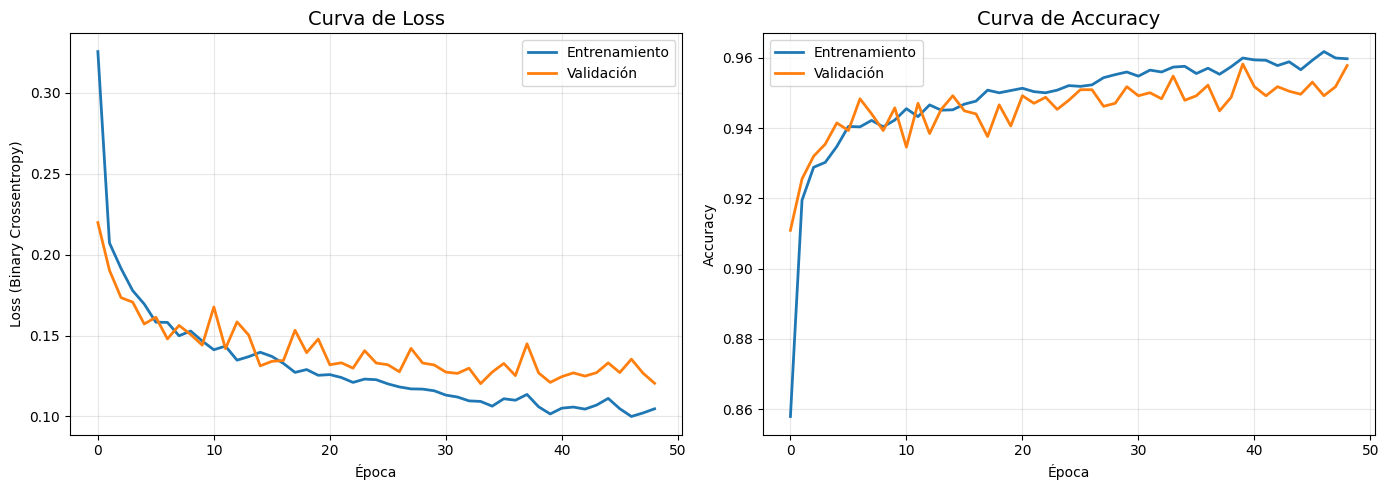

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_final.history['loss'], label='Entrenamiento', linewidth=2)
ax1.plot(history_final.history['val_loss'], label='Validación', linewidth=2)
ax1.set_title('Curva de Loss', fontsize=14)
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss (Binary Crossentropy)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_final.history['accuracy'], label='Entrenamiento', linewidth=2)
ax2.plot(history_final.history['val_accuracy'], label='Validación', linewidth=2)
ax2.set_title('Curva de Accuracy', fontsize=14)
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()

Se puede apreciar que la generalización sobre datos no vistos (los de validación) es más inestable.
Esto se puede asociar a ruido o pocos datos de entrenamiento/validación.

### Métricas de clasificación
Se calculan métricas estándar para clasificación binaria:
- **Accuracy**: proporción de predicciones correctas
- **Precision**: de los predichos positivos, cuántos son realmente positivos
- **Recall**: de los realmente positivos, cuántos fueron detectados
- **F1-Score**: media armónica de precision y recall
- **AUC-ROC**: capacidad del modelo para distinguir entre clases

In [14]:
y_pred_proba = modelo_final.predict(X_test).flatten()
y_pred = (y_pred_proba >= 0.3).astype(int) # esto queda más sensible a fallas, antes era 0,5

print("=== Reporte de Clasificación ===\n")
print(classification_report(y_test, y_pred,
                            target_names=['No falla (0)', 'Falla (1)']))

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc_score:.4f}")

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
=== Reporte de Clasificación ===

              precision    recall  f1-score   support

No falla (0)       0.98      0.91      0.94      1408
   Falla (1)       0.92      0.98      0.95      1497

    accuracy                           0.95      2905
   macro avg       0.95      0.94      0.95      2905
weighted avg       0.95      0.95      0.95      2905

AUC-ROC: 0.9893


### Matriz de confusión
Muestra la distribución de predicciones correctas e incorrectas.
Permite identificar si el modelo falla más en falsos positivos (predice falla cuando no la hay) o falsos negativos (no detecta fallas reales).

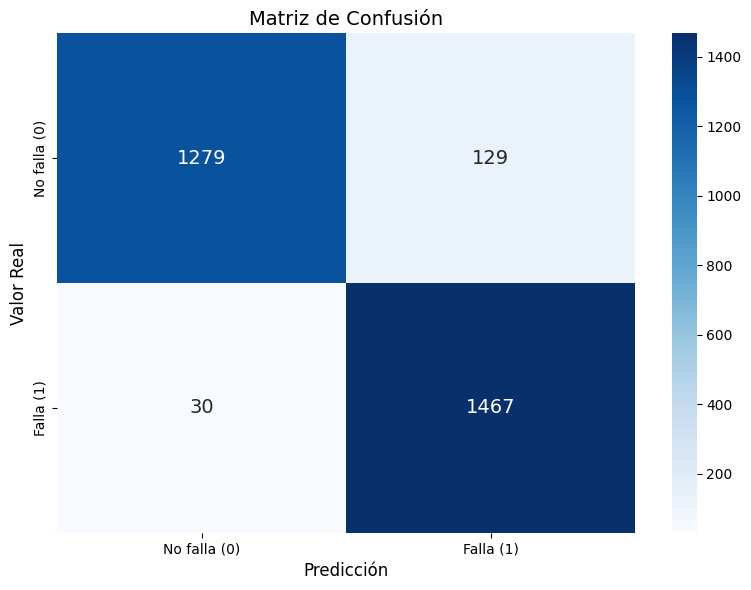

In [15]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No falla (0)', 'Falla (1)'],
            yticklabels=['No falla (0)', 'Falla (1)'],
            ax=ax, annot_kws={"size": 14})
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Valor Real', fontsize=12)
ax.set_title('Matriz de Confusión', fontsize=14)
plt.tight_layout()
# plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### Curva ROC
La curva ROC grafica la tasa de verdaderos positivos (TPR) vs. la tasa de falsos positivos (FPR) para distintos umbrales de decisión. Un AUC cercano a 1.0 indica excelente capacidad discriminativa.

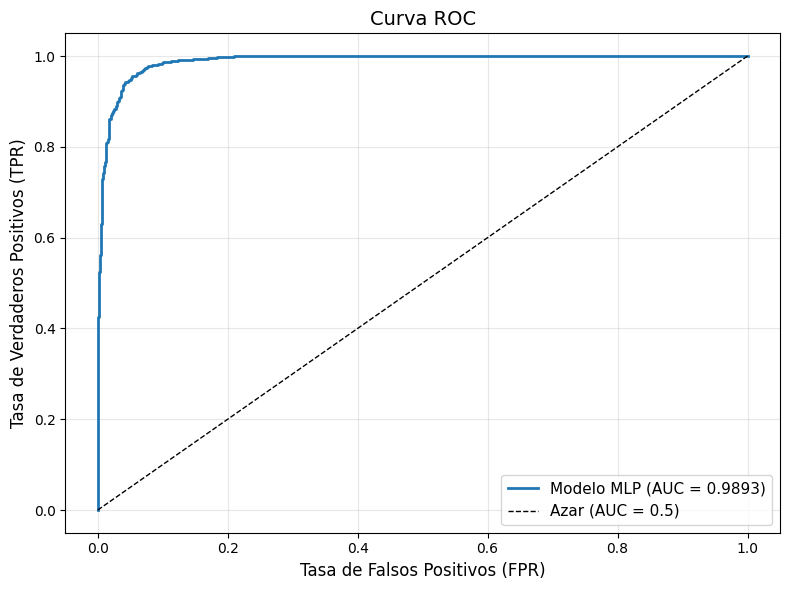

In [16]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, linewidth=2, label=f'Modelo MLP (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Azar (AUC = 0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curva ROC', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## Actividad 4 y 5
El desarrollo de las actividades 4 y 5 se encuentra en el informe correspondiente.